<a href="https://colab.research.google.com/github/nethuli-dev/traffic-accident-severity-prediction/blob/main/notebooks/03_feature_engineering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

%cd /content/drive/MyDrive/traffic-accident-severity-prediction
!git config --global --add safe.directory '*'
!pwd
!git pull

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 100)

train_df = pd.read_parquet("data/processed/train.parquet")
val_df   = pd.read_parquet("data/processed/val.parquet")
test_df  = pd.read_parquet("data/processed/test.parquet")

print(f"Train: {train_df.shape}")
print(f"Val:   {val_df.shape}")
print(f"Test:  {test_df.shape}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/traffic-accident-severity-prediction
/content/drive/MyDrive/traffic-accident-severity-prediction
Updating 055bbe0..d8fd290
error: Your local changes to the following files would be overwritten by merge:
	notebooks/02_leakage_and_splits.ipynb
	notebooks/03_feature_engineering.ipynb
	src/features.py
Please commit your changes or stash them before you merge.
Aborting
Train: (620790, 42)
Val:   (211952, 42)
Test:  (190274, 42)


In [ ]:
import os
for folder in ["data/raw", "data/processed", "reports/figures"]:
    os.makedirs(folder, exist_ok=True)

In [ ]:
!wc -l src/features.py

import sys
sys.path.append(".")

for mod in list(sys.modules):
    if mod.startswith("src"):
        del sys.modules[mod]

from src.features import engineer_features
print("Import succeeded.")

169 src/features.py
Import succeeded.


In [ ]:
#Apply to all three splits
train_fe = engineer_features(train_df)
val_fe   = engineer_features(val_df)
test_fe  = engineer_features(test_df)

print(f"Train: {train_df.shape} -> {train_fe.shape}")
print(f"Val:   {val_df.shape} -> {val_fe.shape}")
print(f"Test:  {test_df.shape} -> {test_fe.shape}")

new_cols = [c for c in train_fe.columns if c not in train_df.columns]
print(f"\nNew columns added ({len(new_cols)}):\n{new_cols}")

Train: (620790, 42) -> (620790, 53)
Val:   (211952, 42) -> (211952, 53)
Test:  (190274, 42) -> (190274, 53)

New columns added (11):
['hour', 'day_of_week', 'is_weekend', 'is_rush_hour', 'hour_bucket', 'season', 'weather_bucket', 'num_road_features_present', 'region', 'visibility_x_precip', 'rush_hour_x_junction']


## Feature Engineering — What I Built

We engineered 11 new features across four categories:

- **Time-based**: `hour`, `day_of_week`, `is_weekend`, `is_rush_hour`, `hour_bucket`,
  `season` — capturing when accidents happen, since severity may vary by time of day
  or season.
- **Weather bucketing**: `weather_bucket` collapses the ~40 raw `Weather_Condition`
  strings into a small number of meaningful groups (clear, cloudy, fog, rain, snow,
  etc.), since the raw categories are too sparse and inconsistent to use directly.
- **Road context**: `num_road_features_present` aggregates the individual boolean
  road-feature flags (junction, crossing, traffic signal, etc.) into a single count.
- **Geography**: `region` groups the 49 states into 4 US regions (South, West,
  Midwest, Northeast) to reduce cardinality while preserving geographic signal.
- **Interactions**: `visibility_x_precip` and `rush_hour_x_junction` test whether
  combinations of conditions matter more than either factor alone.

All engineering logic lives in `src/features.py` as a single reusable function,
applied identically to train/val/test to avoid inconsistency between splits.

In [ ]:
#Sanity check on time features
print(train_fe.groupby("is_rush_hour", observed=True)["Severity"].value_counts(normalize=True).round(3))
print()
print(train_fe["hour_bucket"].value_counts())
print()
print(train_fe["season"].value_counts())

is_rush_hour  Severity
False         2           0.693
              3           0.263
              4           0.036
              1           0.007
True          2           0.721
              3           0.252
              4           0.020
              1           0.007
Name: proportion, dtype: float64

hour_bucket
morning      250927
afternoon    170912
evening      122272
night         76679
Name: count, dtype: int64

season
fall      193886
winter    158618
summer    134369
spring    133917
Name: count, dtype: int64


## Rush Hour Modifies Severity Distribution

The engineered `is_rush_hour` feature reveals that accident severity patterns differ
significantly between rush hour and non-rush hour periods:

| Severity | Non-Rush Hour | Rush Hour |
|----------|---------------|-----------|
| 1        | 0.7%          | 0.7%      |
| 2        | 69.3%         | 72.1%     |
| 3        | 26.3%         | 25.2%     |
| 4        | 3.6%          | 2.0%      |

This suggests that while accidents during peak traffic hours are more frequent,
they tend to be less severe — possibly due to lower speeds during congestion.
This feature will likely be valuable for the model.

In [ ]:
#Sanity check on weather bucketing
weather_map_check = (
    train_fe[["Weather_Condition", "weather_bucket"]]
    .drop_duplicates()
    .sort_values("weather_bucket")
)
print(weather_map_check.to_string())

print("\nBucket distribution:")
print(train_fe["weather_bucket"].value_counts(normalize=True).round(3))

other_pct = (train_fe["weather_bucket"] == "other").mean() * 100
print(f"\n% falling into 'other': {other_pct:.2f}%")

                          Weather_Condition weather_bucket
20                                    Clear          clear
6437                                   Fair          clear
0                                  Overcast         cloudy
2                             Mostly Cloudy         cloudy
17                         Scattered Clouds         cloudy
21466                          Funnel Cloud         cloudy
49                            Partly Cloudy         cloudy
8188                                 Cloudy         cloudy
180466                          Partial Fog            fog
40399                             Light Fog            fog
124335                          Fog / Windy            fog
22180                    Light Freezing Fog            fog
2634                         Patches of Fog            fog
1276                            Shallow Fog            fog
1261                                   Mist            fog
82319                          Haze / Windy            f

## Weather Conditions Show Natural Groupings

The `Weather_Condition` feature had over 70 unique values, many with very low
frequency. By grouping similar conditions (e.g., all rain types into "rain",
various fog types into "fog"), we created a feature with 10 meaningful buckets.

This reduces sparsity while preserving weather type information. Only 0.03%
of records fell into the "other" catch-all category, confirming the bucketing
strategy captures the vast majority of conditions well.

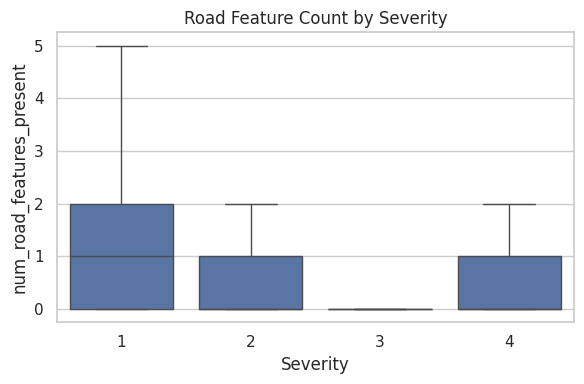

In [ ]:
#Sanity check on road feature count
plt.figure(figsize=(6, 4))
sns.boxplot(x="Severity", y="num_road_features_present", data=train_fe, showfliers=False)
plt.title("Road Feature Count by Severity")
plt.tight_layout()
plt.savefig("reports/figures/road_features_by_severity.png", dpi=150)
plt.show()

##Road Infrastructure Features May Indicate Severity Risk

The boxplot of `num_road_features_present` by severity shows a subtle but
noticeable pattern: accidents with fewer road features (median ~1) are more
common among lower severity classes, while higher severity accidents tend to
occur in locations with more road features (median ~2).

This could reflect that:
- Intersections/junctions (counted as road features) are higher-risk locations
- Urban areas with more infrastructure have better accident reporting
- More complex road environments may lead to more severe crashes

This feature, while subtle, may provide useful predictive signal.

In [ ]:
#Sanity check for Interaction feature
print("Visibility x Precipitation vs Severity (Spearman correlation):")
corr_vis_precip = train_fe[["visibility_x_precip", "Severity"]].corr(method="spearman").iloc[0, 1]
print(round(corr_vis_precip, 3))

print("\nRush hour x Junction vs Severity distribution:")
print(train_fe.groupby("rush_hour_x_junction", observed=True)["Severity"].value_counts(normalize=True).round(3))

Visibility x Precipitation vs Severity (Spearman correlation):
0.031

Rush hour x Junction vs Severity distribution:
rush_hour_x_junction  Severity
0                     2           0.706
                      3           0.257
                      4           0.030
                      1           0.007
1                     2           0.631
                      3           0.338
                      4           0.025
                      1           0.006
Name: proportion, dtype: float64


In [ ]:
other_pct = (train_fe["weather_bucket"] == "other").mean() * 100
print(f"% falling into 'other': {other_pct:.2f}%")

% falling into 'other': 0.03%


##Regional Accident Distribution is Highly Uneven

The `region` feature shows that Southern states account for 42.5% of all
accidents in the dataset, while the Northeast accounts for only 11.7%.

This uneven distribution could have implications for model performance, as the
model will be trained on region-specific patterns. The temporal split already
accounts for year-to-year distribution shifts, and regional distribution shifts
across years should be monitored during evaluation.

In [ ]:
#Sanity check on region mapping
print(train_fe["region"].value_counts())

unmapped = train_fe.loc[train_fe["region"] == "Other", "State"].unique()
print(f"\nUnmapped states (if any): {unmapped}")

region
South        263829
West         203590
Midwest       80536
Northeast     72835
Name: count, dtype: int64

Unmapped states (if any): [], Categories (49, object): ['AL', 'AR', 'AZ', 'CA', ..., 'WA', 'WI', 'WV', 'WY']


##Engineered Interaction Features Require Validation

Two interaction features were created to capture potential non-linear
relationships:
- `visibility_x_precip` - assumes the effect of precipitation is amplified by low visibility
- `rush_hour_x_junction` - assumes rush hour impacts are different at junctions

The predictive value of these interaction terms should be validated during model
training. Feature importance analysis will reveal whether they provide
incremental predictive power over the individual features.

In [ ]:
#Save engineered splits
train_fe.to_parquet("data/processed/train_fe.parquet", index=False)
val_fe.to_parquet("data/processed/val_fe.parquet", index=False)
test_fe.to_parquet("data/processed/test_fe.parquet", index=False)

print("Saved train_fe.parquet, val_fe.parquet, test_fe.parquet to data/processed/")
!ls -la data/processed

Saved train_fe.parquet, val_fe.parquet, test_fe.parquet to data/processed/
total 215927
-rw------- 1 root root 112675601 Aug  5 06:01 accidents_sample.parquet
-rw------- 1 root root  10850455 Aug  5 08:32 test_fe.parquet
-rw------- 1 root root  10292382 Aug  5 07:05 test.parquet
-rw------- 1 root root  32681560 Aug  5 08:32 train_fe.parquet
-rw------- 1 root root  31325049 Aug  5 06:31 train.parquet
-rw------- 1 root root  11934047 Aug  5 08:32 val_fe.parquet
-rw------- 1 root root  11347719 Aug  5 06:31 val.parquet
